In [14]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

data = pd.read_csv('../../data/openpowerlifting.csv')


data.dropna(axis=0, how='any', inplace=True)
data = data[data['Sex'] != 'F']
data['Sex'].unique()

array(['M'], dtype=object)

In [15]:
data[['BestSquatKg', 'BestDeadliftKg']]


,BestSquatKg,BestDeadliftKg
2574,165.00,200.00
2720,117.50,182.50
2785,137.50,182.50
2814,240.00,300.00
3972,147.50,195.00
3973,147.50,195.00
4206,67.50,105.00
4209,92.50,112.50
4688,95.00,167.50
4747,195.00,237.50


In [16]:
# Drop rows where any column in X or y has NaN



X_full, X_test, y_full, y_test = train_test_split(
    data[['BestSquatKg']], data[["BestDeadliftKg"]]
)

X_full["BestSquatKg"].fillna(X_full["BestSquatKg"].mean(), inplace=True)
y_full["BestDeadliftKg"].fillna(y_full["BestDeadliftKg"].mean(), inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_13188\107457688.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_full["BestSquatKg"].fillna(X_full["BestSquatKg"].mean(), inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_13188\107457688.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [17]:
X_train, X_valid, y_train, y_valid = train_test_split(X_full, y_full)

type(X_train)


pandas.core.frame.DataFrame

In [18]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)


y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(y_train)
y_valid = y_scaler.transform(y_valid)
y_test  = y_scaler.transform(y_test)

type(y_train)
type(X_train)

numpy.ndarray

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_mae",
    patience=3,
    restore_best_weights=True
)

In [20]:
model = keras.models.Sequential([
    keras.layers.Dense(32, activation='relu',  input_shape=(X_train.shape[1],)),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics=['mae'])

c:\Users\user\Desktop\machine_learning\ts_env\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
import matplotlib.pyplot as plt

history = model.fit(
    X_train, y_train,
    epochs=30,  
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop])


Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.2271 - mae: 0.4267 - val_loss: 0.5828 - val_mae: 0.6813
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.2202 - mae: 0.4197 - val_loss: 0.5693 - val_mae: 0.6725
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.2137 - mae: 0.4129 - val_loss: 0.5561 - val_mae: 0.6637
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.2073 - mae: 0.4061 - val_loss: 0.5431 - val_mae: 0.6550
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.2010 - mae: 0.3993 - val_loss: 0.5302 - val_mae: 0.6463
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.1948 - mae: 0.3926 - val_loss: 0.5176 - val_mae: 0.6377
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.1887 - mae: 0.3858 - val_loss: 0.5051 - val_mae: 0.6291
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.1828 - mae: 0.3795 - val_loss: 0.4929 - val_mae: 0.6206
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1770 - mae: 0.3

,loss,mae,val_loss,val_mae
0,0.227104,0.426711,0.582844,0.681259
1,0.220240,0.419689,0.569306,0.672457
2,0.213686,0.412868,0.556097,0.663741
3,0.207270,0.406077,0.543066,0.655035
4,0.200972,0.399302,0.530218,0.646343


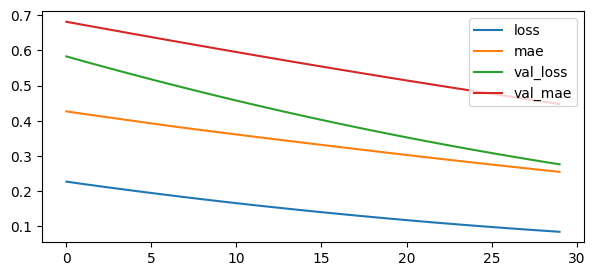

In [22]:

pd.DataFrame(history.history).plot(figsize=(7,3))
pd.DataFrame(history.history).head()


In [23]:
import numpy as np

squat_input = np.array([[130]])              # raw bench in kg
bench_input_scaled = scaler.transform(squat_input)

pred_scaled = model.predict(bench_input_scaled)  # output ~0–1
pred_kg = y_scaler.inverse_transform(pred_scaled)

print("Predicted Deadlift (kg):", pred_kg[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


c:\Users\user\Desktop\machine_learning\ts_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Deadlift (kg): 142.40468


In [ ]:
import tensorflowjs as tfjs


tfjs.converters.save_keras_model(model, "gym_model")


ModuleNotFoundError: No module named 'tensorflowjs'